# 03b · Functional features from the NIAK preprocessed COBRE release

This notebook builds the functional half of the analysis from the release you downloaded:
`COBRE preprocessed with NIAK 0.12.14` (figshare 1160600, CC BY-NC), 146 participants.

Nothing is unzipped: each participant's image is decompressed in memory, one at a time.

## What this release already contains
The NIAK pipeline has already done the preprocessing (see the archive's `README.md`):
- slice-timing and rigid-body motion correction;
- coregistration to each participant's T1 and non-linear normalization to **MNI152 2009a symmetric**, resampled to **3 mm**;
- **scrubbing**: volumes with FD > 0.5 mm removed, so participants have different numbers of volumes (40–150);
- **nuisance regression**: slow drifts (0.01 Hz high-pass cosines), principal components of the 6 motion parameters and their squares, plus average white-matter and ventricle signals;
- **6 mm smoothing**.

Each participant has:
- `fmri_<id>_session1_run1.nii.gz`: the 4-D preprocessed BOLD image, 53 × 64 × 52 × T, TR = 2 s;
- `fmri_<id>_session1_run1_extra.mat`: `confounds` (already regressed out), `labels_confounds`, `mask_suppressed` (which raw volumes were dropped) and `time_frames` (times of the kept volumes);
- a row in `cobre_model_group.csv`: `sz` (1 = patient), `age`, `sex` (**0 = male**) and `FD` (mean framewise displacement).

**What we do not redo:** no second confound regression and no second scrubbing. Denoising the data twice would distort the signal.

## Protocol changes this forces (recorded in protocol §13, before the lock)

| Protocol item | Original | Now | Why |
|---|---|---|---|
| **D3 processing route** | raw BIDS → fMRIPrep with FreeSurfer | **verified NIAK 0.12.14 derivatives** | The raw COBRE T1s are still pending, and fMRIPrep needs Docker and tens of GB, which this machine does not have |
| §3.3 denoising | nilearn `scrubbing` strategy on fMRIPrep confounds | NIAK's own strategy, listed above | fixed by the release |
| Denoising sensitivity analyses | `simple`, `scrubbing_gsr` | **not available** | the release ships one denoising |
| tSNR as a quality covariate | median voxel mean/SD | **not available** | tSNR is meaningless after denoising and smoothing |
| Confound set (D9) | age, sex, mean FD, eTIV, surface holes, tSNR | **age, sex, mean FD** | the others need the structural data |
| D8 motion rule | ≥ 180 s retained | **≥ 180 s primary**, ≥ 120 s (NIAK's own rule) as a labelled sensitivity analysis | NIAK already scrubbed at FD > 0.5 mm; the rule now decides how much scrubbed data is enough |

**Atlas-space caveat.** nilearn ships the Schaefer atlas in FSL MNI152 space at 2 mm, while these images are in MNI152 2009a symmetric at 3 mm. The masker resamples the atlas onto the data grid, which leaves small misalignments at region borders. This is recorded as a limitation; a TemplateFlow atlas in the matching space would remove it.

**Status: preliminary and exploratory.** The protocol is not locked and the structural half is missing, so results from these features are exploratory and are labelled as such.

In [1]:
from pathlib import Path
from functools import partial
import gzip
import io
import json
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
use_notebook("01_dataset_audit.ipynb")        # map_value, parse_number, value handling rules
use_notebook("03_functional_features.ipynb")  # fisher_z, upper_triangle, edge_table, load_atlas, roi_network

In [3]:
import nibabel as nib
from joblib import Parallel, delayed
from nilearn.maskers import NiftiLabelsMasker

NIAK_TR_SECONDS = 2.0                          # README: TR = 2 s
NIAK_LABEL_MAP = {"patient": [1], "control": [0]}     # the 'sz' column
NIAK_SEX_MAP = {"male": [0], "female": [1]}           # 0 = male (README: 58/72 patients, 51/74 controls are male)


def niak_members(archive):
    """{participant id: {'nii': member, 'mat': member}} for every participant in the archive."""
    with zipfile.ZipFile(archive) as archive_file:
        names = archive_file.namelist()
    members = {}
    for name in names:
        if name.endswith("_extra.mat"):
            members.setdefault(name.split("_")[1], {})["mat"] = name
        elif name.endswith(".nii.gz"):
            members.setdefault(name.split("_")[1], {})["nii"] = name
    return members


def niak_manifest(archive, phenotype_file="cobre_model_group.csv", min_retained_seconds=180,
                  sensitivity_seconds=120):
    """Labels, covariates and retained scan time for every participant in the archive."""
    members = niak_members(archive)
    rows = []
    with zipfile.ZipFile(archive) as archive_file:
        pheno = pd.read_csv(io.BytesIO(archive_file.read(phenotype_file)), skipinitialspace=True)
        pheno.columns = ["participant_raw"] + [str(c).strip() for c in pheno.columns[1:]]
        for _, record in pheno.iterrows():
            raw_id = str(record["participant_raw"]).strip()
            files = members[raw_id]
            extra = scipy.io.loadmat(io.BytesIO(archive_file.read(files["mat"])))
            label = map_value(record["sz"], NIAK_LABEL_MAP, "sz")
            sex = map_value(record["sex"], NIAK_SEX_MAP, "sex")
            if label is None or sex is None:
                raise ValueError(f"{raw_id}: missing diagnosis or sex in the phenotype file")
            retained = int(extra["time_frames"].size)
            rows.append({
                "participant_id": f"sub-{raw_id}",
                "participant_raw": raw_id,
                "label": {"patient": 1, "control": 0}[label],
                "age": parse_number(record["age"], "age"),
                "sex_male": {"male": 1, "female": 0}[sex],
                "mean_fd": parse_number(record["FD"], "FD"),
                "n_retained": retained,
                "retained_seconds": retained * NIAK_TR_SECONDS,
                "n_suppressed": int(np.asarray(extra["mask_suppressed"]).sum()),
                "n_raw_volumes": int(np.asarray(extra["mask_suppressed"]).size),
                "nii": files["nii"],
            })
    manifest = pd.DataFrame(rows)
    manifest["included"] = (manifest["retained_seconds"] >= min_retained_seconds).astype(int)
    manifest["included_sensitivity"] = (manifest["retained_seconds"] >= sensitivity_seconds).astype(int)
    return manifest


def niak_flow(manifest, thresholds=(180, 120)):
    """How many participants survive each retained-time rule, by group."""
    rows = [("initial_N", len(manifest)),
            ("patients", int((manifest["label"] == 1).sum())),
            ("controls", int((manifest["label"] == 0).sum()))]
    for seconds in thresholds:
        keep = manifest["retained_seconds"] >= seconds
        rows += [(f">= {seconds}s retained: N", int(keep.sum())),
                 (f">= {seconds}s retained: patients", int((keep & (manifest["label"] == 1)).sum())),
                 (f">= {seconds}s retained: controls", int((keep & (manifest["label"] == 0)).sum()))]
    return pd.DataFrame(rows, columns=["step", "n"])


def participant_connectome_niak(archive, nifti_member, atlas_image):
    """Fisher-z Pearson connectivity for one participant, read straight from the archive."""
    with zipfile.ZipFile(archive) as archive_file:
        image = nib.Nifti1Image.from_bytes(gzip.decompress(archive_file.read(nifti_member)))
    masker = NiftiLabelsMasker(labels_img=atlas_image, standardize="zscore_sample", resampling_target="data")
    series = masker.fit_transform(image)     # NIAK already denoised: nothing is regressed out here
    if np.any(series.std(axis=0) == 0):
        raise ValueError(f"{nifti_member}: an ROI has a constant time series")
    return upper_triangle(fisher_z(np.corrcoef(series, rowvar=False))), series.shape[0]


def extract_niak_features(archive, manifest, atlas_cfg, n_jobs=6):
    """Connectivity features for every participant in ``manifest`` (rows stay in manifest order)."""
    atlas_image, names = load_atlas(atlas_cfg)
    edges = edge_table(names, [roi_network(n) for n in names])
    results = Parallel(n_jobs=n_jobs)(
        delayed(participant_connectome_niak)(archive, member, atlas_image) for member in manifest["nii"])
    features = pd.DataFrame([r[0] for r in results], columns=edges["feature"].tolist())
    features.insert(0, "participant_id", manifest["participant_id"].to_numpy())
    quality = pd.DataFrame({"participant_id": manifest["participant_id"].to_numpy(),
                            "n_volumes_used": [r[1] for r in results]})
    return features, edges, quality

## Build the manifest
This reads the phenotype table and all 146 `_extra.mat` files from the archive. The value-handling rules from notebook 01 apply, so an unexpected code in `sz` or `sex` would stop the run instead of turning into a missing value.

In [4]:
cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
niak_cfg = cfg["niak"]
archive = Path(niak_cfg["archive"])
print("archive:", archive, f"({archive.stat().st_size / 1e9:.1f} GB)")

manifest = niak_manifest(archive, niak_cfg["phenotype_file"],
                         niak_cfg["qc"]["min_retained_seconds"], niak_cfg["qc"]["sensitivity_seconds"])
manifest.to_csv(ROOT / "data" / "participants_manifest_niak.csv", index=False)
display(niak_flow(manifest, (niak_cfg["qc"]["min_retained_seconds"], niak_cfg["qc"]["sensitivity_seconds"])))
display(manifest.head(3))

archive: C:\Users\diksh\Downloads\1160600.zip (8.9 GB)


,step,n
0,initial_N,146
1,patients,72
2,controls,74
3,>= 180s retained: N,82
4,>= 180s retained: patients,31
5,>= 180s retained: controls,51
6,>= 120s retained: N,101
7,>= 120s retained: patients,43
8,>= 120s retained: controls,58


,participant_id,participant_raw,label,age,sex_male,mean_fd,n_retained,retained_seconds,n_suppressed,n_raw_volumes,nii,included,included_sensitivity
0,sub-szxxx0040000,szxxx0040000,1,20.0,0,0.18,146,292.0,4,150,fmri_szxxx0040000_session1_run1.nii.gz,1,1
1,sub-szxxx0040001,szxxx0040001,1,27.0,1,0.50,40,80.0,110,150,fmri_szxxx0040001_session1_run1.nii.gz,0,0
2,sub-szxxx0040002,szxxx0040002,1,19.0,1,0.21,83,166.0,67,150,fmri_szxxx0040002_session1_run1.nii.gz,0,1


## Describe the sample before modelling
Head motion is the confound to watch: patients moved more, so more of their data was scrubbed. That is visible in both panels below, and it is why the confounds-only baseline in notebook 09 matters.

,group,n,age_mean,age_sd,male_pct,mean_fd_mean,mean_fd_sd,retained_s_mean,retained_s_min
0,control,74,35.8,11.6,68.9,0.230,0.061,216.0,80.0
1,patient,72,38.2,13.9,80.6,0.276,0.099,166.4,80.0


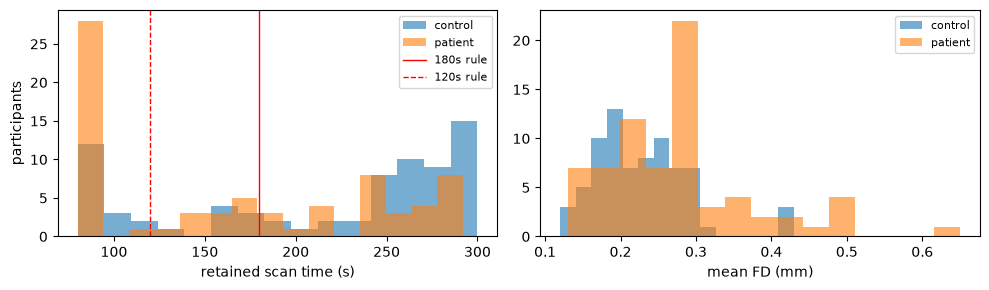

In [5]:
groups = manifest.groupby("label")
display(pd.DataFrame([{
    "group": "patient" if label == 1 else "control", "n": len(g),
    "age_mean": g["age"].mean().round(1), "age_sd": g["age"].std().round(1),
    "male_pct": (100 * g["sex_male"].mean()).round(1),
    "mean_fd_mean": g["mean_fd"].mean().round(3), "mean_fd_sd": g["mean_fd"].std().round(3),
    "retained_s_mean": g["retained_seconds"].mean().round(1),
    "retained_s_min": g["retained_seconds"].min(),
} for label, g in groups]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for label, name in [(0, "control"), (1, "patient")]:
    subset = manifest[manifest["label"] == label]
    axes[0].hist(subset["retained_seconds"], bins=15, alpha=0.6, label=name)
    axes[1].hist(subset["mean_fd"], bins=15, alpha=0.6, label=name)
for seconds, style in [(niak_cfg["qc"]["min_retained_seconds"], "-"), (niak_cfg["qc"]["sensitivity_seconds"], "--")]:
    axes[0].axvline(seconds, color="red", ls=style, lw=1, label=f"{seconds}s rule")
axes[0].set(xlabel="retained scan time (s)", ylabel="participants")
axes[1].set(xlabel="mean FD (mm)")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Extract the connectivity features
For each participant: decompress in memory → Schaefer-100 ROI time series (z-scored over time) → Pearson correlation → Fisher z → upper triangle, giving 4,950 edges.

Features are extracted for **all 146** participants so that both motion rules can be analysed; the rule is applied when the design matrix is built (notebook 09).

In [6]:
import time

start = time.perf_counter()
features, edges, quality = extract_niak_features(archive, manifest, cfg["functional"]["atlas"], n_jobs=6)
print(f"{len(features)} participants x {len(edges)} edges in {time.perf_counter() - start:.0f} s")

out = ROOT / cfg["features_dir"]
out.mkdir(parents=True, exist_ok=True)
features.to_csv(out / "functional_features_niak.csv", index=False, float_format="%.6g")
edges.to_csv(out / "functional_edges.csv", index=False)
quality.to_csv(out / "functional_qc_niak.csv", index=False)
print("written to", out.relative_to(ROOT))

[fetch_atlas_schaefer_2018] Dataset directory found: C:\Users\diksh\OneDrive\Desktop\mri\mkl-project\data\derivatives\atlases\schaefer_2018


146 participants x 4950 edges in 81 s


written to data\derivatives\features


## Checks on the extracted features
- every participant is present, in manifest order;
- the number of volumes used matches the manifest's retained count;
- no missing values;
- the connectivity values look plausible (within-network stronger than between-network).

features: 146 participants x 4950 edges
mean Fisher z, within network:  +0.532
mean Fisher z, between network: +0.287
value range: -1.29 to +2.68


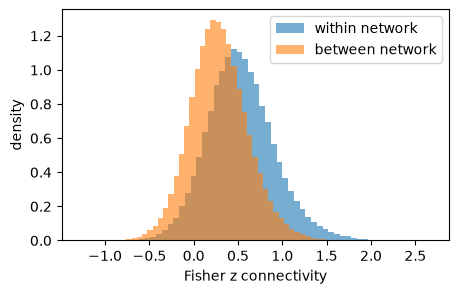

In [7]:
assert list(features["participant_id"]) == list(manifest["participant_id"])
assert (quality["n_volumes_used"].to_numpy() == manifest["n_retained"].to_numpy()).all()
values = features.drop(columns="participant_id").to_numpy(float)
assert np.isfinite(values).all()

same_network = (edges["network_i"] == edges["network_j"]).to_numpy()
print(f"features: {values.shape[0]} participants x {values.shape[1]} edges")
print(f"mean Fisher z, within network:  {values[:, same_network].mean():+.3f}")
print(f"mean Fisher z, between network: {values[:, ~same_network].mean():+.3f}")
print(f"value range: {values.min():+.2f} to {values.max():+.2f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(values[:, same_network].ravel(), bins=60, alpha=0.6, density=True, label="within network")
ax.hist(values[:, ~same_network].ravel(), bins=60, alpha=0.6, density=True, label="between network")
ax.set(xlabel="Fisher z connectivity", ylabel="density")
ax.legend()
plt.show()